Tarefas 
- entender porque o shap do tradicional gbr nao esta compativel com o artigo. sera que foi usado set de treino? 
- terminar de importar os codigos de injecao de ruidos e analises morfologicas
- Consolidar todas as "observacao" para melhor entendimento
- Em relação ao Shap values entender as diferencas nos tipos de graficos



# 0. Imports and global configuration


In [3]:
import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:

RANDOM_STATE = 42
TEST_SIZE = 0.2

GBR_PARAMS = dict(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)


# 1. Data loading and description 

In [5]:
FILE_PATH = "./content/dados_jamovi.xlsx"
TARGET_COL = "Velocity (mean) [µm/s]"

data = pd.read_excel(FILE_PATH)

if TARGET_COL not in data.columns:
    raise ValueError(f"Target não encontrada: {TARGET_COL}")

numeric_data = data.select_dtypes(include=[np.number])

# 2. Declare predictors and target variable

In [6]:
X = numeric_data.drop(columns=[TARGET_COL])
y = numeric_data[TARGET_COL]

mask = X.notna().all(axis=1) & y.notna()
X, y = X.loc[mask], y.loc[mask]

# 3. Split train and test set

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# 3. Modeling Experiments

## Experiment A - Traditional Gradient Boosting Regressor 


### Train and predict

In [8]:
def train_gbr(X_train, y_train, X_test, params):
    model = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    return model.predict(X_test), model 

In [9]:
y_pred_a, trad_gbr_model = train_gbr(X_train, y_train, X_test, GBR_PARAMS)

df_eval_a = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_a,
    "residuals": y_test - y_pred_a,
    "experiment": "Traditional GBR"
})



## Experiment B - Physics-based feature engineering Gradient Boosting Regressor (PFE - GBR)


### Feature Engineering - Phisical features

In [10]:
def compute_physics_features(df, target_col):
    rho_f = 1000.0
    mu = 0.001
    g = 9.81
    rho_p = 2600.0

    A = df["Area (mean) [µm²]"] * 1e-12
    r = df["Radius (max) (mean) [µm]"] * 1e-6
    v = df[target_col] * 1e-6  # ⚠️ leakage explícito

    d = 2.0 * np.sqrt(A / np.pi)

    Re = (rho_f * v * d) / mu
    Re = Re.where(Re > 0).replace([np.inf, -np.inf], np.nan)

    Cd = 24.0 / Re
    Fd = 0.5 * rho_f * Cd * A * v**2
    r2 = r**2
    Stokes = (2 / 9) * ((rho_p - rho_f) * g * r2 / mu)

    return pd.DataFrame({
        "PFE_Re": Re,
        "PFE_Cd": Cd,
        "PFE_Fd": Fd,
        "PFE_r2": r2
    }, index=df.index)


In [11]:
physics_features = compute_physics_features(data.loc[X.index], TARGET_COL)

X_train_pfe = pd.concat(
    [X_train, physics_features.loc[X_train.index]], axis=1
)
X_test_pfe = pd.concat(
    [X_test, physics_features.loc[X_test.index]], axis=1
)



### Training model

In [12]:
y_pred_b, pfe_gbr_model = train_gbr(
    X_train_pfe, y_train,
    X_test_pfe,
    GBR_PARAMS
)

df_eval_b = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_b,
    "residuals": y_test - y_pred_b,
    "experiment": "PFE-GBR"
})


In [13]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


In [14]:

results = pd.DataFrame.from_dict({
    "Traditional GBR": evaluate(y_test, y_pred_a),
    "PFE-GBR": evaluate(y_test, y_pred_b)
}, orient="index")

results

,MAE,RMSE,R2
Traditional GBR,200.583157,348.754576,0.898693
PFE-GBR,126.239043,225.069464,0.957808


# 4. Holdout Evaluation and Error Interpretation

In [15]:
df_eval = pd.concat([df_eval_a, df_eval_b], axis=0).copy()

df_eval_trad = df_eval[df_eval["experiment"] == "Traditional GBR"]
df_eval_pfe  = df_eval[df_eval["experiment"] == "PFE-GBR"]

## Real vs Predicted Velocity


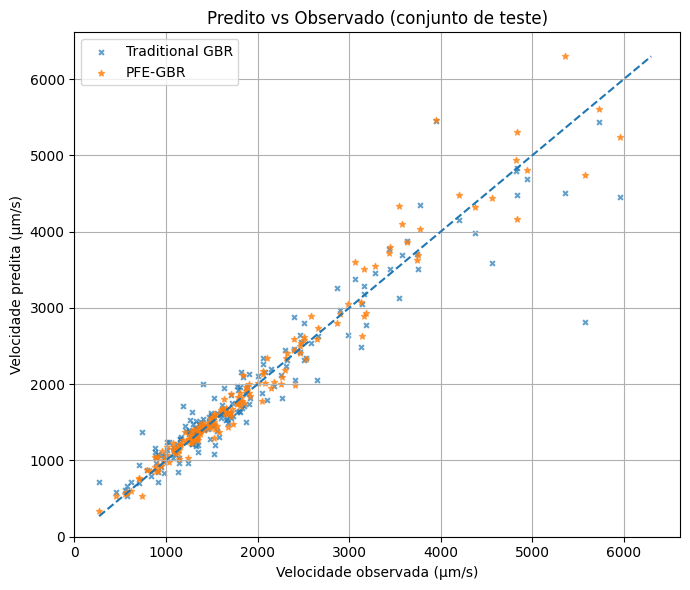

In [16]:
plt.figure(figsize=(7, 6))

for df_, label, marker, size in [
    (df_eval_trad, "Traditional GBR", "x", 12),
    (df_eval_pfe,  "PFE-GBR", "*", 20),
]:
    plt.scatter(
        df_["y_true"],
        df_["y_pred"],
        marker=marker,
        s=size,
        alpha=0.7,
        label=label
    )

lims = [
    min(df_eval["y_true"].min(), df_eval["y_pred"].min()),
    max(df_eval["y_true"].max(), df_eval["y_pred"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])
plt.ylim([lims[0]-1*lims[0],lims[1]+0.05*lims[1]])

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado (conjunto de teste)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Error Analysis

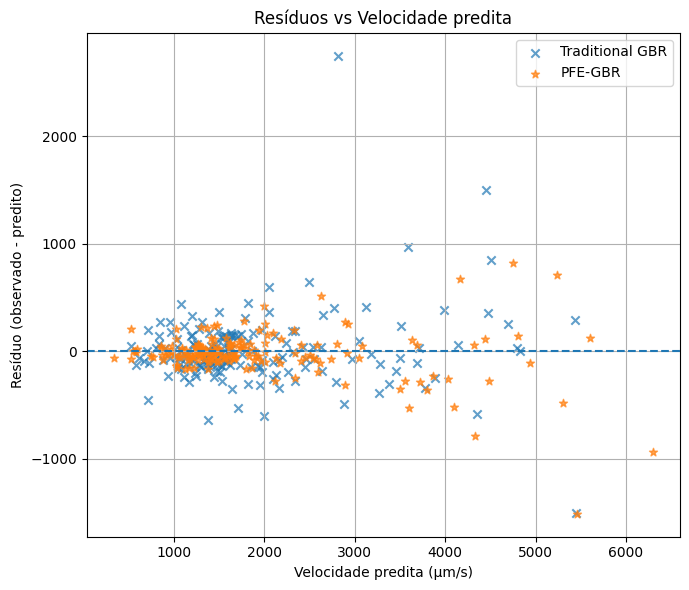

In [26]:
plt.figure(figsize=(7, 6))

plt.scatter(
    df_eval_trad["y_pred"],
    df_eval_trad["residuals"],
    marker="x",
    alpha=0.7,
    label="Traditional GBR"
)

plt.scatter(
    df_eval_pfe["y_pred"],
    df_eval_pfe["residuals"],
    marker="*",
    alpha=0.7,
    label="PFE-GBR"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Velocidade predita (µm/s)")
plt.ylabel("Resíduo (observado - predito)")
plt.title("Resíduos vs Velocidade predita")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Model Interpretability - SHAP Values

##### Observacao 

Mesmo o codigo do professor apresenta resultados de shap diferentes do artigo. as tendencias sao similares, mas nao da pra falar que sao a mesma coisa

## shap.TreeExplainer

### Tradicional GBR

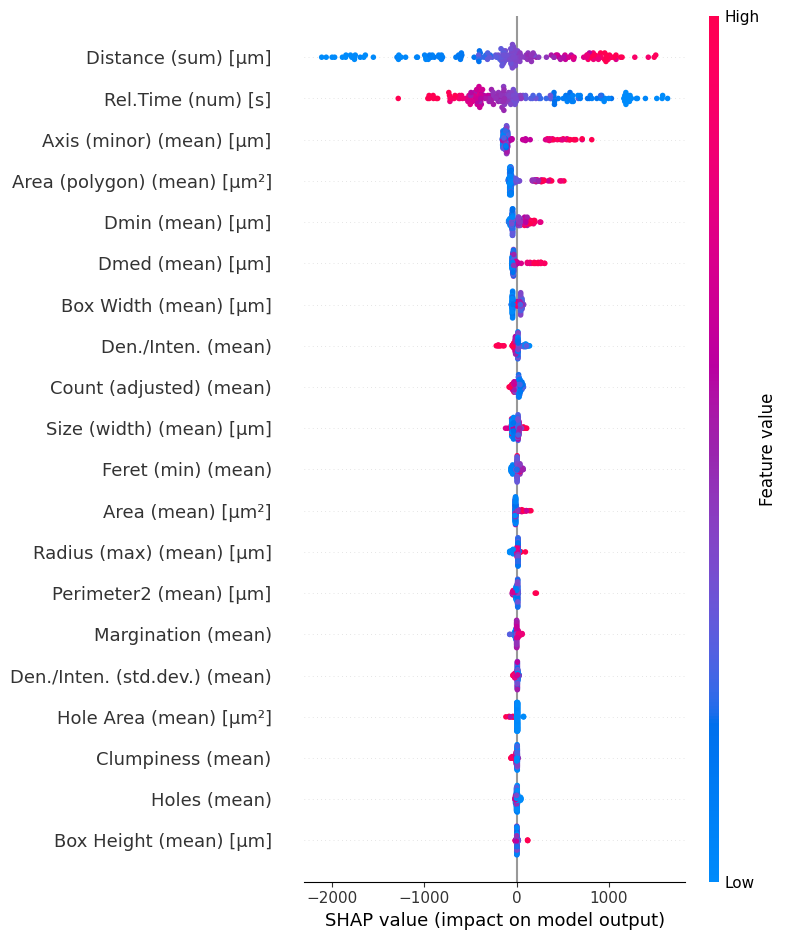

In [18]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.TreeExplainer(trad_gbr_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


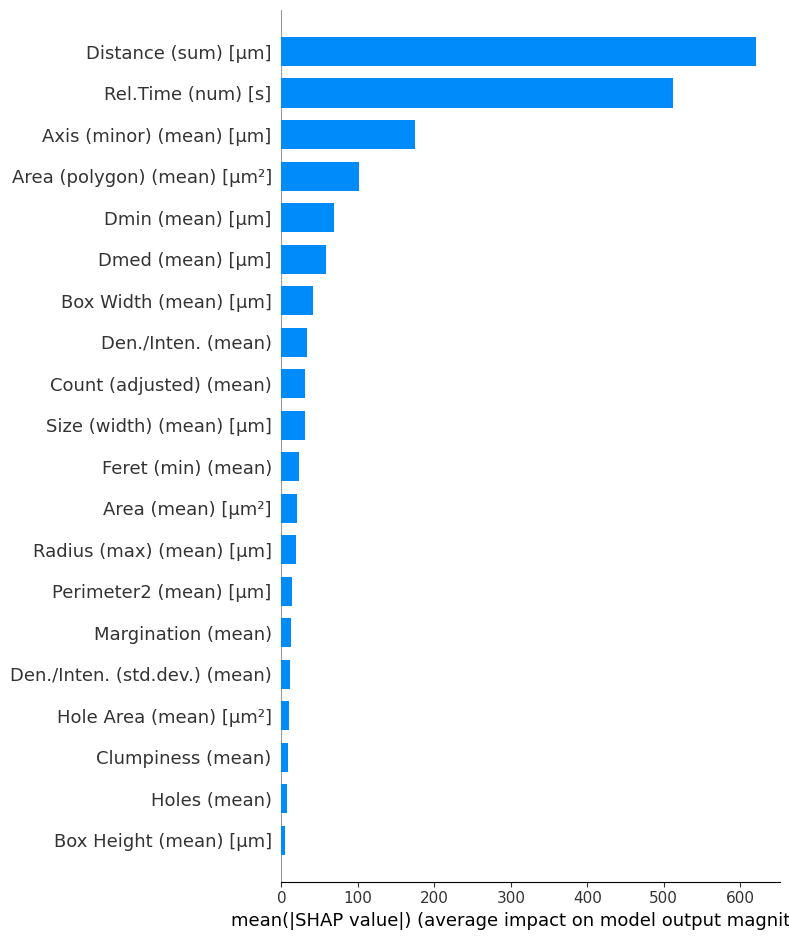

In [19]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

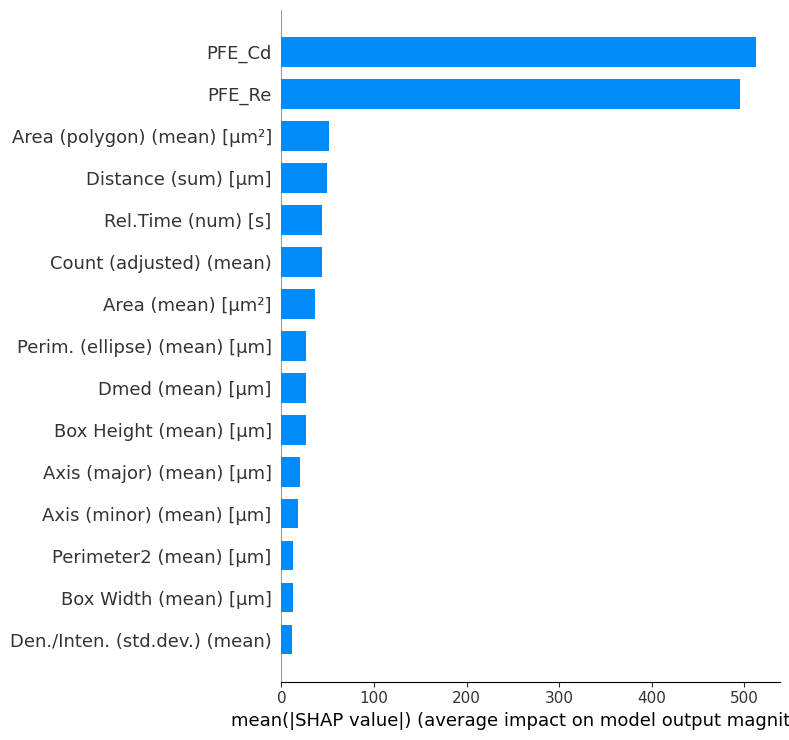

In [20]:
explainer = shap.TreeExplainer(
    pfe_gbr_model
)

shap_values = explainer.shap_values(X_test_pfe)

shap.summary_plot(
    shap_values,
    X_test_pfe,
    plot_type="bar",
    max_display=15
)

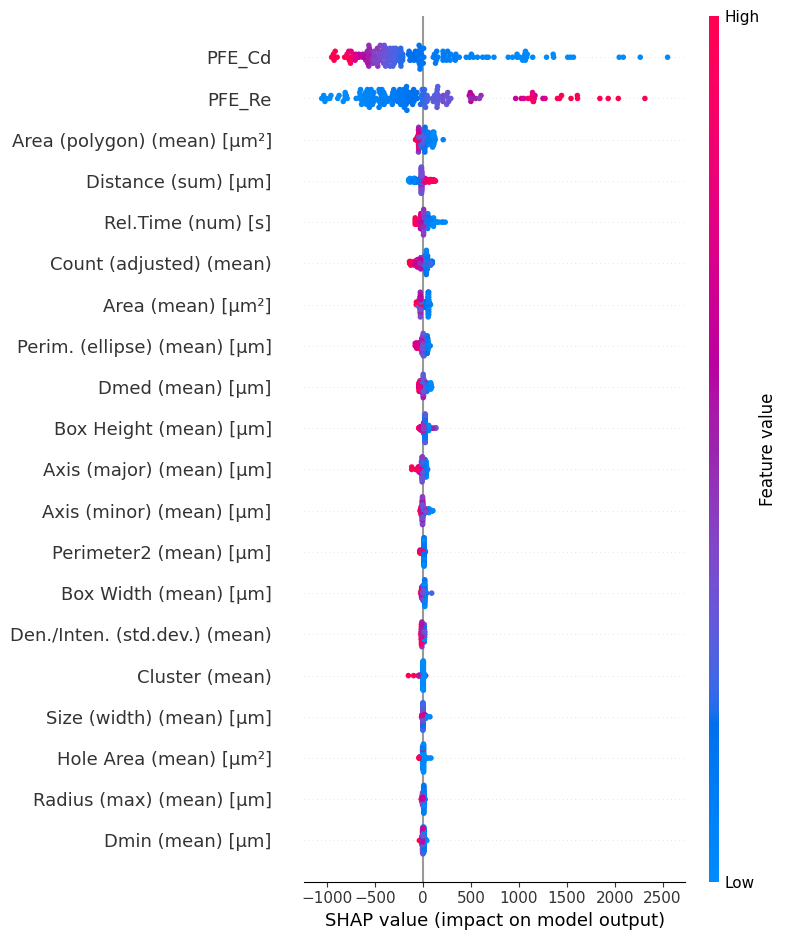

In [21]:
# PFE - GBR
explainer = shap.TreeExplainer(pfe_gbr_model)
shap_values_pfe = explainer.shap_values(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe, show=False)


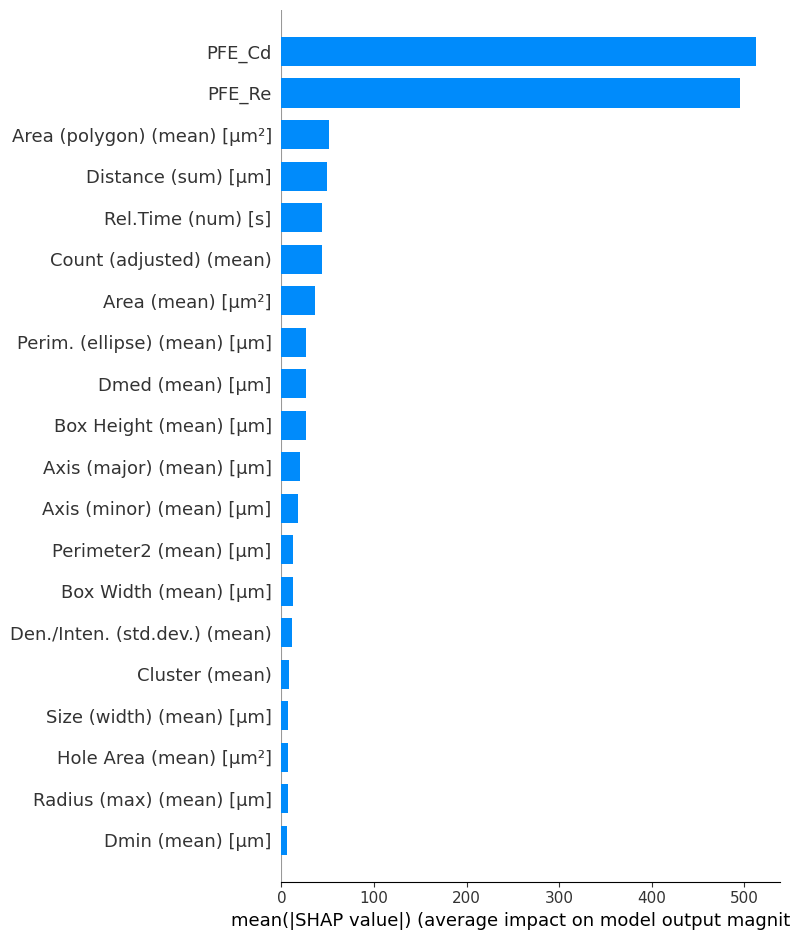

In [22]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

# 6. Bootstrap analysis


In [23]:
def bootstrap_mae(
    y_true,
    y_pred,
    n_boot=100,
    random_state=42
):
    """
    Bootstrap do MAE a partir de pares (y_true, y_pred).

    Parâmetros
    ----------
    y_true : array-like
        Valores observados.
    y_pred : array-like
        Valores preditos pelo modelo (fixos).
    n_boot : int
        Número de reamostragens bootstrap.
    random_state : int
        Seed para reprodutibilidade.

    Retorna
    -------
    dict com:
        mae_boot : np.ndarray
        mean_mae : float
        std_mae  : float
        ci_low   : float (IC 2.5%)
        ci_high  : float (IC 97.5%)
    """
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    n = len(y_true)
    mae_boot = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)  # amostragem com reposição
        mae_boot[i] = mean_absolute_error(
            y_true[idx],
            y_pred[idx]
        )

    mean_mae = mae_boot.mean()
    std_mae  = mae_boot.std(ddof=1)
    ci_low, ci_high = np.percentile(mae_boot, [2.5, 97.5])

    return {
        "mae_boot": mae_boot,
        "mean_mae": mean_mae,
        "std_mae": std_mae,
        "ci_low": ci_low,
        "ci_high": ci_high
    }


In [24]:
bootstrap_results = bootstrap_mae(
    y_true=y_test,
    y_pred=y_pred_b,
    n_boot=100,
    random_state=42
)

print("Bootstrap MAE (PFE-GBR)")
print(f"Média: {bootstrap_results['mean_mae']:.2f} µm/s")
print(f"DP:    {bootstrap_results['std_mae']:.2f} µm/s")
print(
    f"IC 95%: "
    f"[{bootstrap_results['ci_low']:.2f}, "
    f"{bootstrap_results['ci_high']:.2f}] µm/s"
)

Bootstrap MAE (PFE-GBR)
Média: 126.13 µm/s
DP:    14.71 µm/s
IC 95%: [99.41, 159.08] µm/s


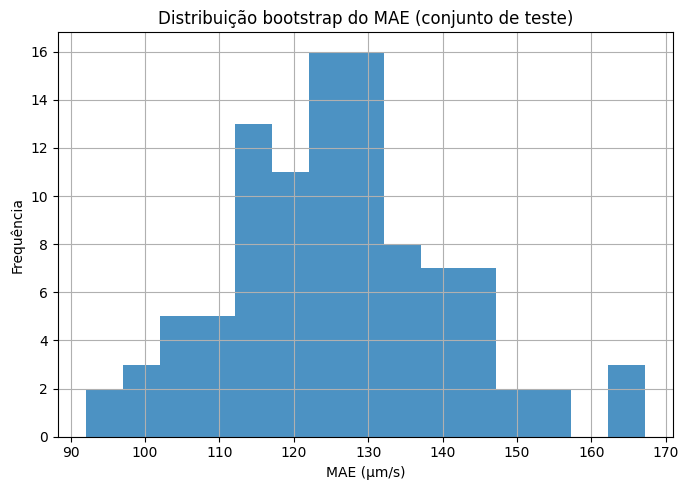

In [25]:
plt.figure(figsize=(7, 5))

plt.hist(
    bootstrap_results["mae_boot"],
    bins=15,
    alpha=0.8
)

plt.xlabel("MAE (µm/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap do MAE (conjunto de teste)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Robustness Analysis - Noise Injection

## 7.1. Performance Degradation Under Noise

# 8. Error Analysis by Morphological Class